<a href="https://colab.research.google.com/github/srivakshita/My-Project/blob/main/Heart_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# =========================
# IMPORT LIBRARIES
# =========================

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import classification_report

# =========================
# LOAD DATASET
# =========================


In [ ]:
#loading the csv data to a Pandas dataFrame
heart_data = pd.read_csv('/content/heart_disease_uci.csv')

# =========================
# SHOW DATA
# =========================


In [ ]:
print(heart_data.head())

   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4             normal    0  


# =========================
# CHECK COLUMN NAMES
# =========================

In [ ]:
print("\nColumn Names:")
print(heart_data.columns)


Column Names:
Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')


# =========================
# LAST COLUMN AS TARGET
# =========================

In [ ]:
target_column = heart_data.columns[-1]

print("\nTarget Column is:", target_column)


Target Column is: num


# =========================
# DATASET INFORMATION
# =========================

In [ ]:
print("\nDataset Shape:")
print(heart_data.shape)

print("\nMissing Values:")
print(heart_data.isnull().sum())



Dataset Shape:
(920, 16)

Missing Values:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


# =========================
# STATISTICAL SUMMARY
# =========================

In [ ]:
print("\nStatistical Summary:")
print(heart_data.describe())


Statistical Summary:
               id         age    trestbps        chol      thalch     oldpeak  \
count  920.000000  920.000000  861.000000  890.000000  865.000000  858.000000   
mean   460.500000   53.510870  132.132404  199.130337  137.545665    0.878788   
std    265.725422    9.424685   19.066070  110.780810   25.926276    1.091226   
min      1.000000   28.000000    0.000000    0.000000   60.000000   -2.600000   
25%    230.750000   47.000000  120.000000  175.000000  120.000000    0.000000   
50%    460.500000   54.000000  130.000000  223.000000  140.000000    0.500000   
75%    690.250000   60.000000  140.000000  268.000000  157.000000    1.500000   
max    920.000000   77.000000  200.000000  603.000000  202.000000    6.200000   

               ca         num  
count  309.000000  920.000000  
mean     0.676375    0.995652  
std      0.935653    1.142693  
min      0.000000    0.000000  
25%      0.000000    0.000000  
50%      0.000000    1.000000  
75%      1.000000    2.0

# ======================================================
# GRAPH 1 : TARGET VARIABLE COUNT
# ======================================================


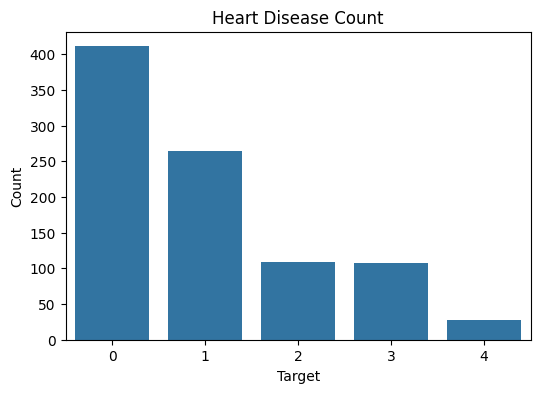

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x=target_column, data=heart_data)

plt.title("Heart Disease Count")
plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

# ======================================================
# GRAPH 2 : AGE DISTRIBUTION
# ======================================================


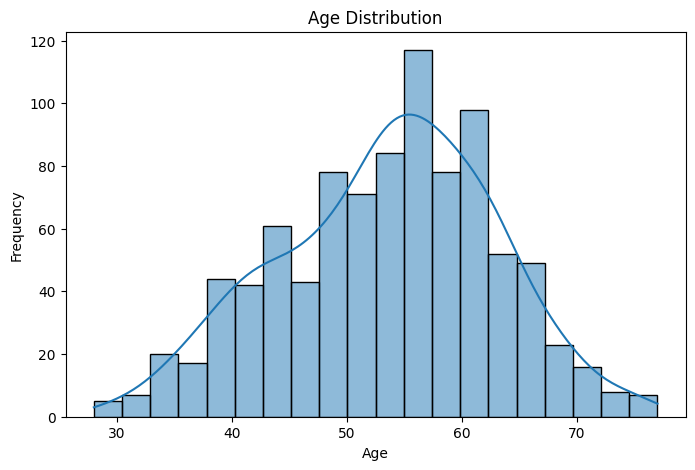

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(heart_data['age'], bins=20, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

# ======================================================
# GRAPH 3 : CORRELATION HEATMAP
# ======================================================

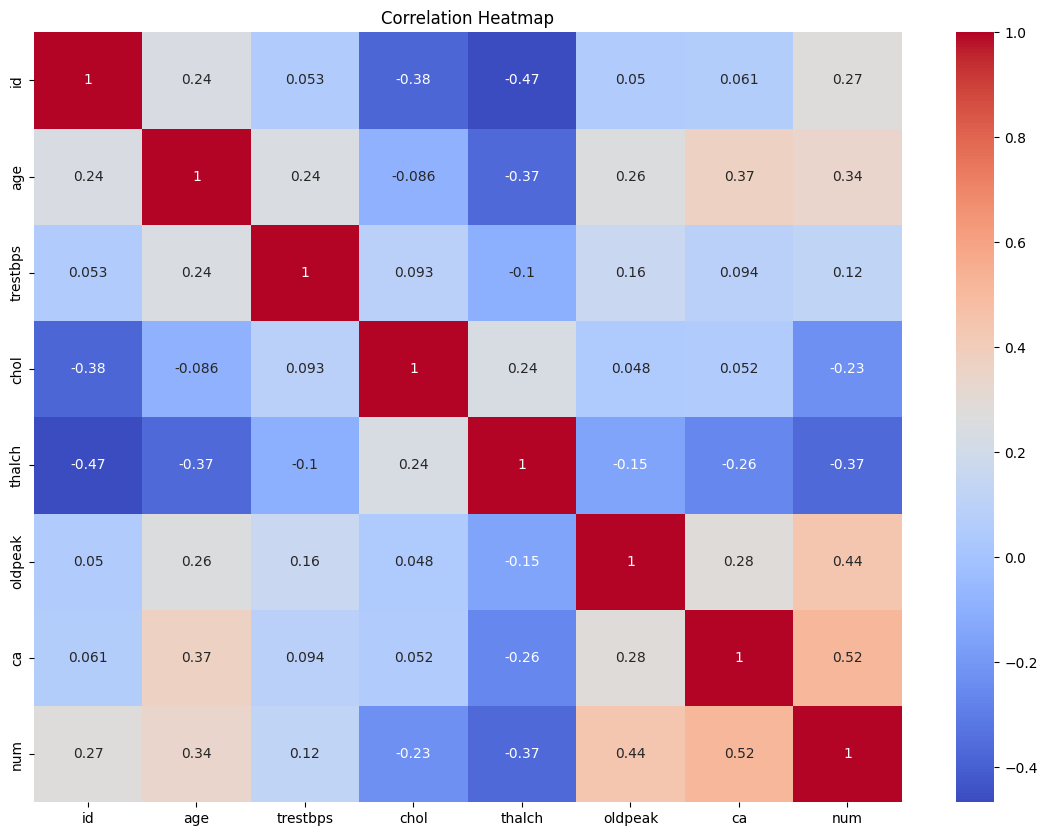

In [ ]:
# Correlation Heatmap

plt.figure(figsize=(14,10))

numeric_data = heart_data.select_dtypes(include=['number'])

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# =========================
# SPLITTING DATA
# =========================

In [ ]:
X = heart_data.drop(columns=target_column, axis=1)

Y = heart_data[target_column]

# =========================
# TRAIN TEST SPLIT
# =========================

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    stratify=Y,
    random_state=2
)

# =========================
# MODEL TRAINING
# =========================

In [ ]:

model = LogisticRegression(max_iter=1000)

model.fit(X_train, Y_train)

print("Model trained successfully")


ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values